# Neural Networks

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In this notebook we build a neural network 'from scratch'. That is, without using any NN libraries like tensorflow, pytorch etc. Just numpy.

We can define the sigmoid function below, a commonly used activation function in neural networks.

In [4]:
def sigmoid(x):
    """Sigmoid function"""
    return 1.0 / (1.0 + np.exp(-x))

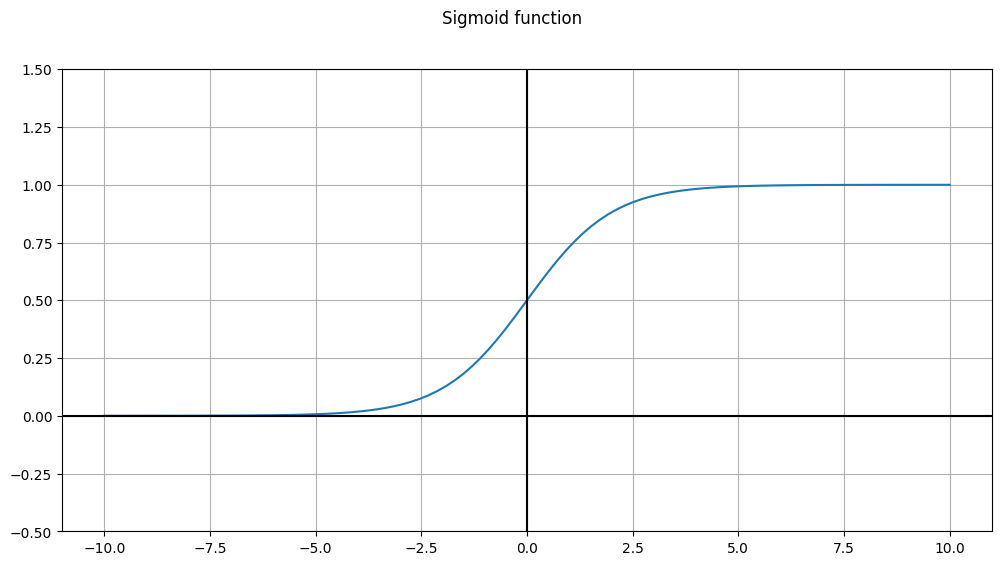

In [5]:
vals = np.linspace(-10, 10, num=100, dtype=np.float32)
activation = sigmoid(vals)
fig = plt.figure(figsize=(12,6))
fig.suptitle('Sigmoid function')
plt.plot(vals, activation)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.yticks()
plt.ylim([-0.5, 1.5]);

## Neurons as logic gates

The sigmoid function is used as an activation function for neurons in a network. A neuron is a node that represents a value somewhere in the network. A single neuron can already be used as a regression model. Where the weights used for the neuron are the parameters of linear regression in the form $\hat{y} = \hat{w}\cdot\hat{x}$, this is when the activation function is simply a linear function. 

With a single neuron we can also represent the function of a logic gate. Below multiple common logic gates are made with a single neuron with 3 inputs. The two input values, and a bias term.

In [31]:
def logic_gate(w1, w2, b):
    # Helper to create logic gate functions
    # Plug in values for weight_a, weight_b, and bias
    return lambda x1, x2: sigmoid(w1 * x1 + w2 * x2 + b)

def test(gate):
    # Helper function to test out our weight functions.
    for a, b in (0, 0), (0, 1), (1, 0), (1, 1):
        print("{}, {}: {}".format(a, b, np.round(gate(a, b))))

In [32]:
or_gate = logic_gate(20, 20, -10)
test(or_gate)

0, 0: 0.0
0, 1: 1.0
1, 0: 1.0
1, 1: 1.0


In [33]:
and_gate = logic_gate(10, 10, -15)
test(and_gate)

0, 0: 0.0
0, 1: 0.0
1, 0: 0.0
1, 1: 1.0


In [34]:
nor_gate = logic_gate(-15, -15, 10)
test(nor_gate)

0, 0: 1.0
0, 1: 0.0
1, 0: 0.0
1, 1: 0.0


In [35]:
nand_gate = logic_gate(-15, -15, 20)
test(nand_gate)

0, 0: 1.0
0, 1: 1.0
1, 0: 1.0
1, 1: 0.0


However, it is not possible to represent the XOR gate in this way. For this we need a more complex structure. This is because the XOR decision boundary is not linearly separable, and thus requires more information. This could be possible by moving the problem into a higher dimensional space (as in with the kernel trick in SVMs) or by using a deeper structure with neurons. This naturally leads to the concept of hidden layers, which encode some properties about the problem space in a latent representation.

The easiest way to set this up is by reusing the existing gates we made above, as we would normally construct an XOR gate from an or gate, a nand gate, and an and gate.

In [36]:
def xor_gate(a, b):
    c = or_gate(a, b)
    d = nand_gate(a, b)
    return and_gate(c, d)
test(xor_gate)

0, 0: 0.0
0, 1: 1.0
1, 0: 1.0
1, 1: 0.0


This creates a more complex structure that has a hidden layer (in the form of the or- and nand-gates) and finally has an output layer from an and gate.

## Networks as matrix calculations.

The above network for the XOR gate can also be expressed as a matrix calculation. The input is an 3 element vector (a, b and the bias term), which is multiplied by a 3x2 matrix. This results in a 2-element vector that represents the outputs c and d. This is then appended with another bias term and multiplied by a 3x1 matrix, resulting in a single value.

For the XOR problem above this looks like:

In [80]:
a = 0
b = 0

xor_input = np.array([a, b, 1])
w1 = np.array(
    [
        [ 20,  20, -10], 
        [-20, -20,  30]
    ]
)
w2 = np.array(
    [
        [ 20,  20, -30]
    ] 
)

sigmoid(
    w2 @ sigmoid(
        np.hstack([w1 @ xor_input, [1]])
    )
)

array([0.12665659])

We can cast this in a function and again use this with out test method from before:

In [83]:
def xor_gate(a, b):
    xor_input = np.array([a, b, 1])
    return sigmoid(w2@sigmoid(np.hstack([w1@xor_input,[1]])))[0]
test(xor_gate)

0, 0: 0.0
0, 1: 1.0
1, 0: 1.0
1, 1: 0.0
